In [1]:
!git clone https://github.com/BuiNguyenQuynhNhu/Vietnam-Fake-News.git fakenew

Cloning into 'fakenew'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 17 (delta 6), reused 17 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 3.65 MiB | 23.35 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
cd fakenew

/content/fakenew


# Package

In [ ]:
!pip install wordcloud underthesea

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from underthesea import word_tokenize, pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset


#EDA

In [ ]:
df = pd.read_csv("data.csv")

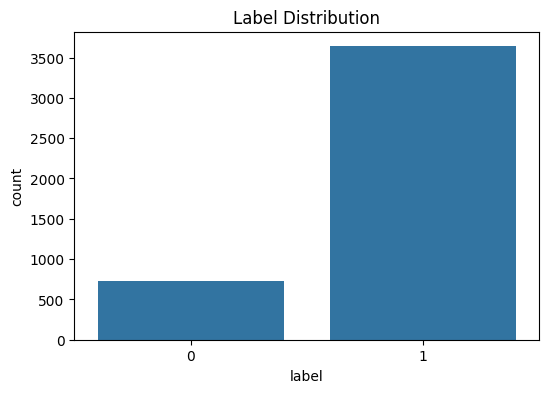

label
1    3638
0     734
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Label Distribution")
plt.show()

print(df["label"].value_counts())

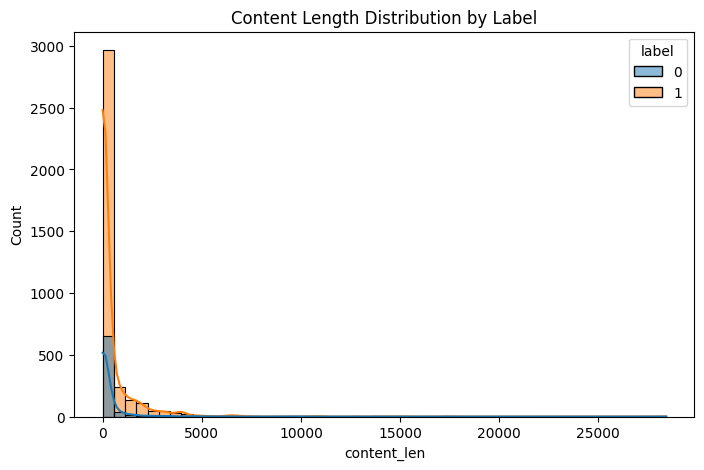

In [6]:
df["content_len"] = df["content"].fillna("").astype(str).apply(len)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Content Length Distribution by Label")
plt.show()

In [7]:
with open("split.json", "r", encoding="utf-8") as f:
    splits = json.load(f)
    train_df = df[df["id"].isin(splits["train"])].copy()
    val_df   = df[df["id"].isin(splits["val"])].copy()
    test_df  = df[df["id"].isin(splits["test"])].copy()

In [8]:
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 3060
Val size: 656
Test size: 656


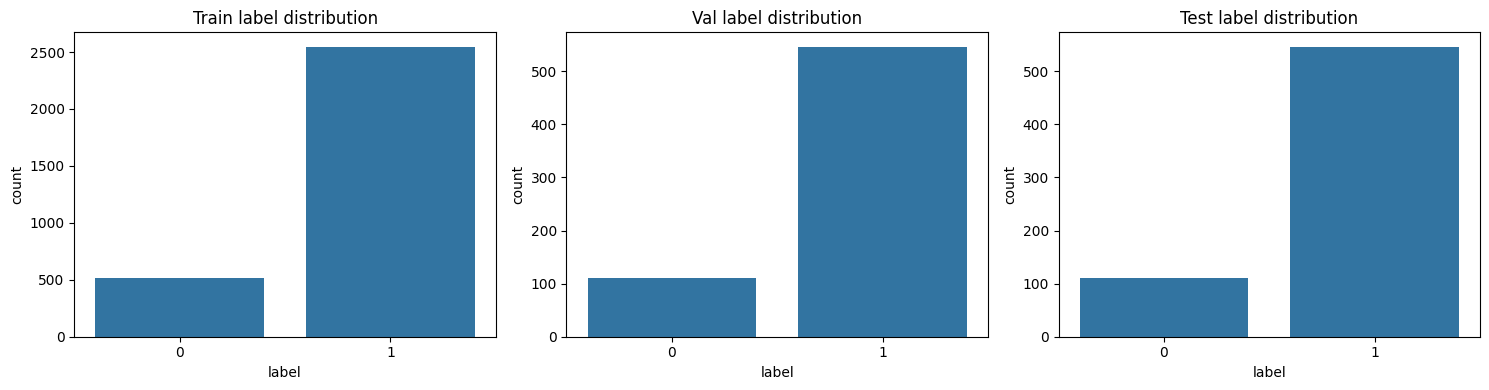

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(data=train_df, x="label", ax=axes[0])
axes[0].set_title("Train label distribution")

sns.countplot(data=val_df, x="label", ax=axes[1])
axes[1].set_title("Val label distribution")

sns.countplot(data=test_df, x="label", ax=axes[2])
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

In [10]:
for d in [train_df, val_df, test_df]:
    d["content_len"] = d["content"].fillna("").astype(str).apply(len)

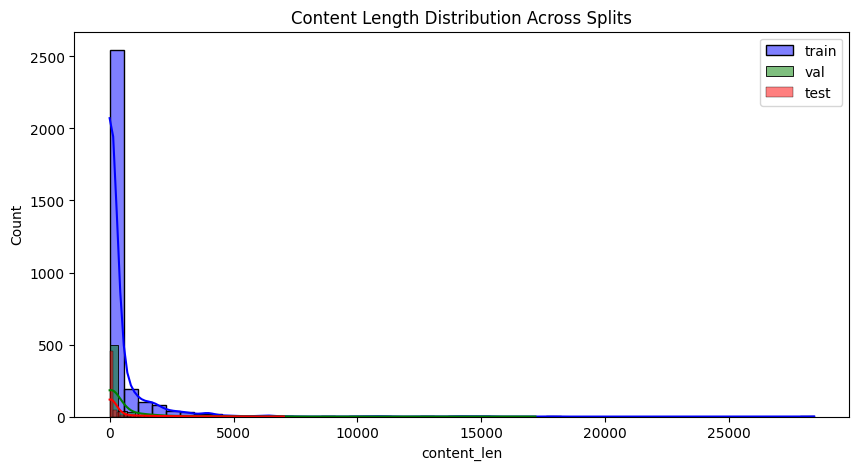

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(train_df["content_len"], label="train", color="blue", kde=True, bins=50)
sns.histplot(val_df["content_len"], label="val", color="green", kde=True, bins=50)
sns.histplot(test_df["content_len"], label="test", color="red", kde=True, bins=50)

plt.legend()
plt.title("Content Length Distribution Across Splits")
plt.show()

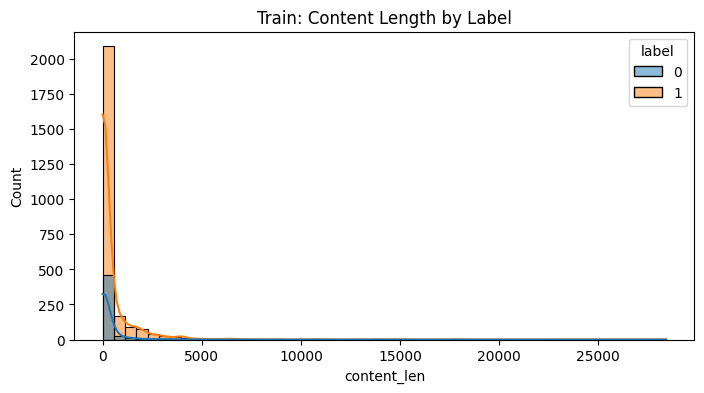

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(data=train_df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Train: Content Length by Label")
plt.show()

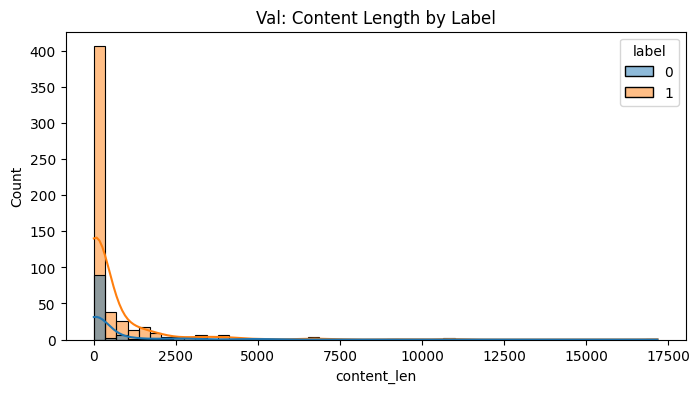

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(data=val_df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Val: Content Length by Label")
plt.show()

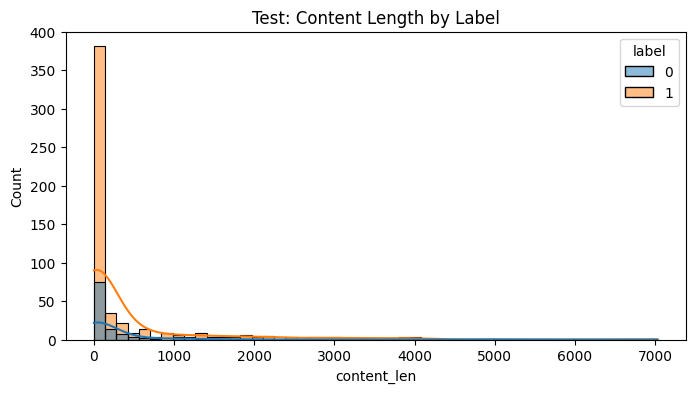

In [14]:
plt.figure(figsize=(8,4))
sns.histplot(data=test_df, x="content_len", hue="label", bins=50, kde=True)
plt.title("Test: Content Length by Label")
plt.show()

In [15]:
def stats(name, d):
    print(f"\n=== {name} ===")
    print(d.groupby("label")["content_len"].describe())

stats("TRAIN", train_df)
stats("VAL", val_df)
stats("TEST", test_df)


=== TRAIN ===
        count        mean          std  min  25%  50%    75%      max
label                                                                
0       514.0  296.040856  1006.485006  0.0  0.0  0.0  201.0  14119.0
1      2546.0  433.613119  1314.149542  0.0  0.0  2.0  260.0  28424.0

=== VAL ===
       count        mean          std  min  25%  50%    75%      max
label                                                               
0      110.0  411.281818  1001.957938  0.0  0.0  0.0  203.5   5349.0
1      546.0  528.135531  1454.094976  0.0  0.0  6.0  367.0  17178.0

=== TEST ===
       count        mean         std  min  25%  50%    75%     max
label                                                             
0      110.0  210.881818  563.252021  0.0  0.0  0.0  208.5  4908.0
1      546.0  397.534799  911.490587  0.0  0.0  2.0  261.0  7028.0


Đã tải thành công 1949 stopwords từ stopwords.txt
--- ĐANG PHÂN TÍCH ĐỘ DÀI TIÊU ĐỀ ---


/tmp/ipykernel_695/3765345248.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='char_count', ax=axes[0], palette='Set2')
/tmp/ipykernel_695/3765345248.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', ax=axes[1], palette='Set2')
/tmp/ipykernel_695/3765345248.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[2], palette='Set2')


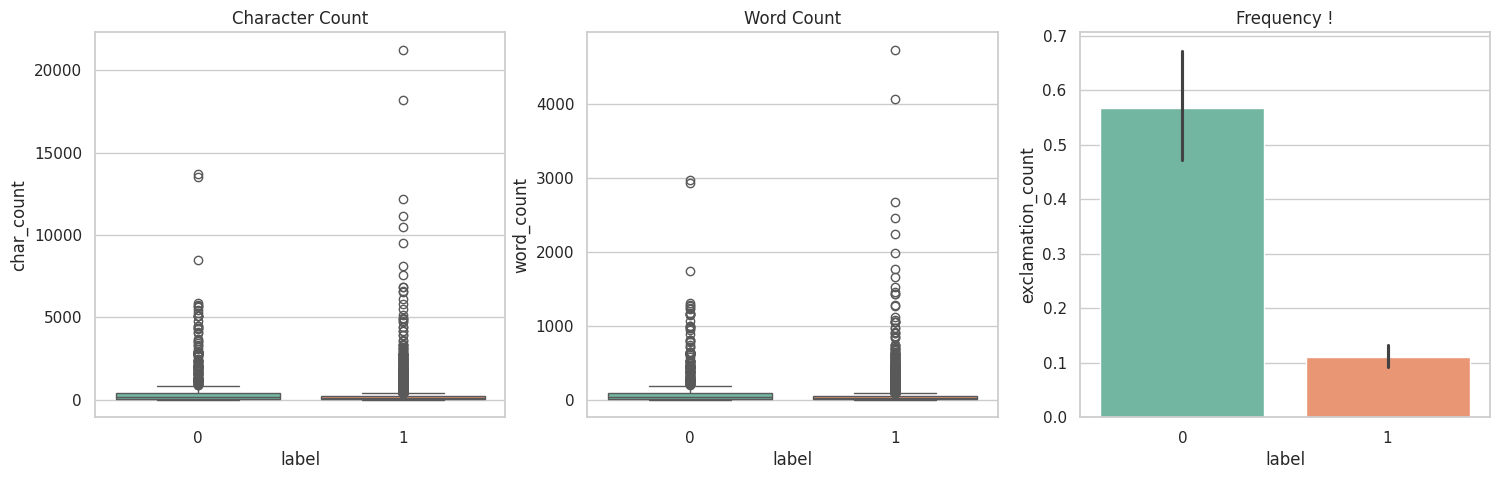

--- ĐANG TẠO WORD FREQUENCY ---


/tmp/ipykernel_695/3765345248.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(common_words.keys()), x=list(common_words.values()), ax=ax, palette='Reds_r' if 'Fake' in title else 'Blues_r')
/tmp/ipykernel_695/3765345248.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=list(common_words.keys()), x=list(common_words.values()), ax=ax, palette='Reds_r' if 'Fake' in title else 'Blues_r')


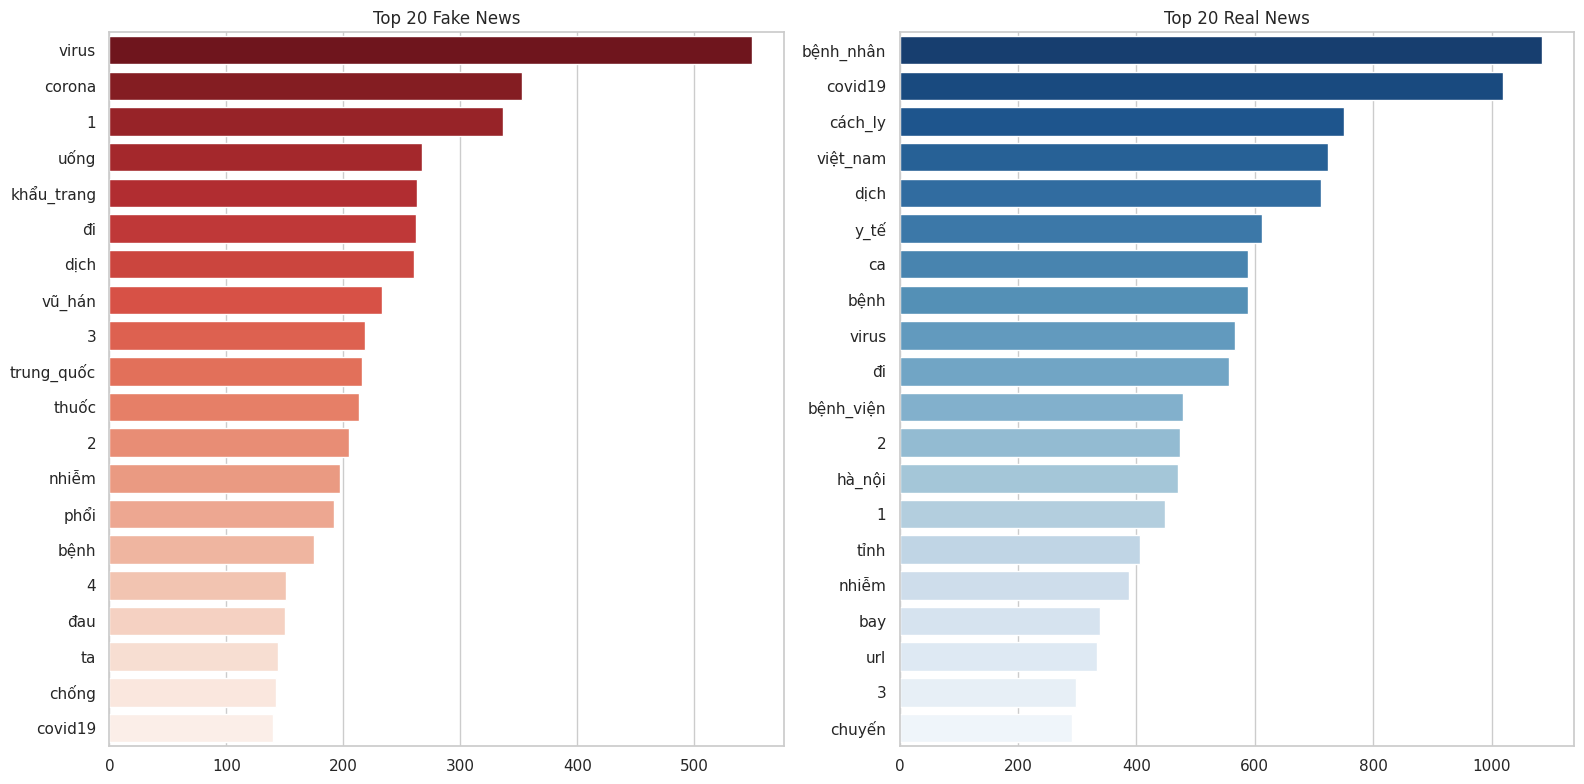

--- ĐANG TẠO WORDCLOUD ---


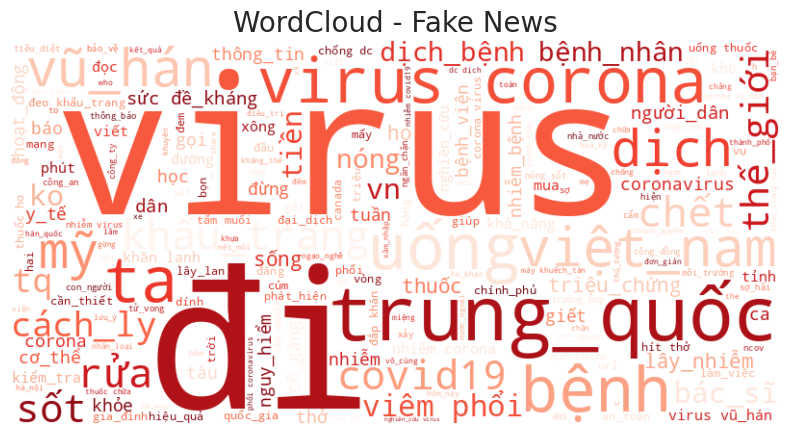

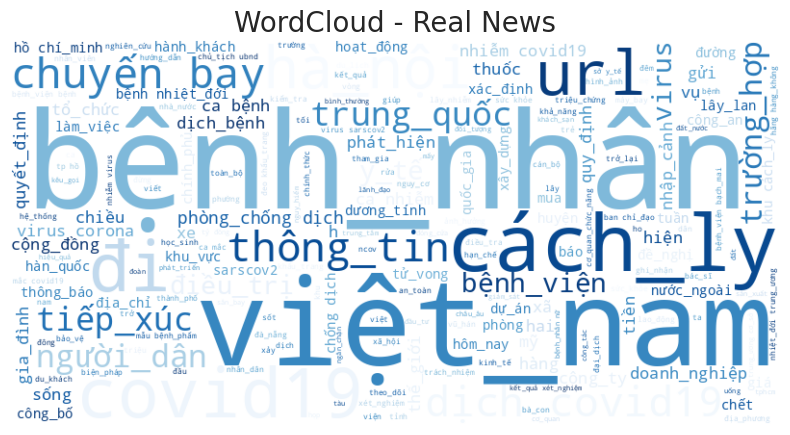

--- ĐANG PHÂN TÍCH VÀ VẼ N-GRAM ---


/tmp/ipykernel_695/3765345248.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=df_ngram, palette=color)


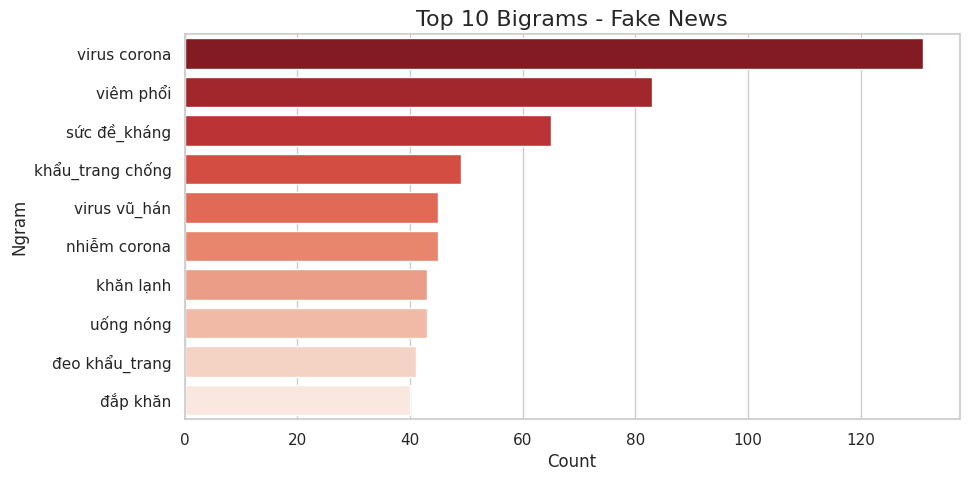

/tmp/ipykernel_695/3765345248.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=df_ngram, palette=color)


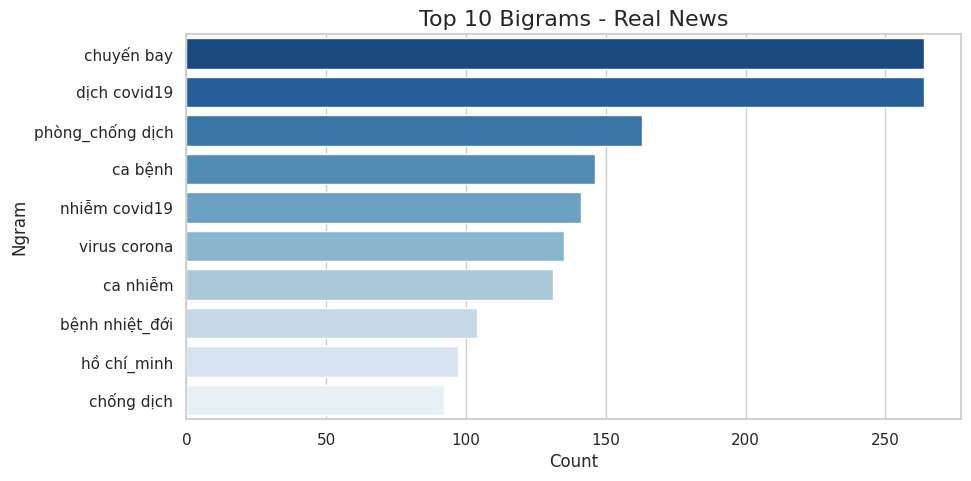

--- ĐANG TỪ TÍNH (POS) & NGỮ NGHĨA ---


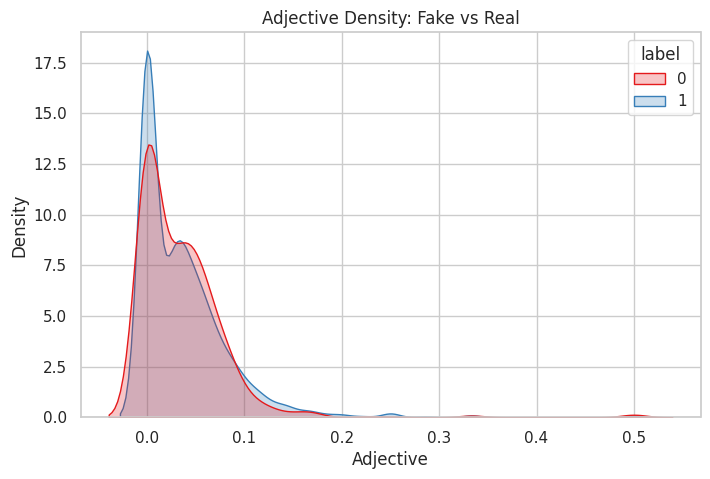

In [17]:
sns.set_theme(style="whitegrid")

stopwords_vn = []
if os.path.exists('stopwords.txt'):
    with open('stopwords.txt', 'r', encoding='utf-8') as f:
        stopwords_vn = [line.strip().replace(' ', '_') for line in f.readlines() if line.strip()]
    print(f"Đã tải thành công {len(stopwords_vn)} stopwords từ stopwords.txt")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
def tokenize_vietnamese(text):
    return word_tokenize(text, format="text")

print("--- ĐANG PHÂN TÍCH ĐỘ DÀI TIÊU ĐỀ ---")
df['char_count'] = df['title'].apply(lambda x: len(str(x)))
df['word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['exclamation_count'] = df['title'].apply(lambda x: str(x).count('!'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='label', y='char_count', ax=axes[0], palette='Set2')
axes[0].set_title('Character Count')

sns.boxplot(data=df, x='label', y='word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Word Count')

sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[2], palette='Set2')
axes[2].set_title('Frequency !')
plt.show()


print("--- ĐANG TẠO WORD FREQUENCY ---")
df['clean_title'] = df['title'].apply(clean_text).apply(tokenize_vietnamese)

fake_titles = ' '.join(df[df['label'] == 0]['clean_title'])
real_titles = ' '.join(df[df['label'] == 1]['clean_title'])

def plot_top_words(text, title, ax, top_n=20):
    words = text.split()
    words = [w for w in words if w not in stopwords_vn]

    counter = Counter(words)
    common_words = dict(counter.most_common(top_n))

    if common_words:
        sns.barplot(y=list(common_words.keys()), x=list(common_words.values()), ax=ax, palette='Reds_r' if 'Fake' in title else 'Blues_r')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_top_words(fake_titles, 'Top 20 Fake News', axes[0])
plot_top_words(real_titles, 'Top 20 Real News', axes[1])
plt.tight_layout()
plt.show()

print("--- ĐANG TẠO WORDCLOUD ---")
def generate_wordcloud(text, title, colormap):
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          colormap=colormap, stopwords=set(stopwords_vn)).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

generate_wordcloud(fake_titles, 'WordCloud - Fake News', 'Reds')
generate_wordcloud(real_titles, 'WordCloud - Real News', 'Blues')

print("--- ĐANG PHÂN TÍCH VÀ VẼ N-GRAM ---")
def get_top_ngrams(corpus, n=10, ngram_range=(2,2)):
    # Đưa stopwords_vn vào CountVectorizer
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=stopwords_vn if stopwords_vn else None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

def plot_ngrams(ngram_data, title, color):
    if not ngram_data:
        return
    df_ngram = pd.DataFrame(ngram_data, columns=['Ngram', 'Count'])
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Count', y='Ngram', data=df_ngram, palette=color)
    plt.title(title, fontsize=16)
    plt.show()

fake_bigrams = get_top_ngrams(df[df['label'] == 0]['clean_title'], n=10, ngram_range=(2,2))
plot_ngrams(fake_bigrams, 'Top 10 Bigrams - Fake News', 'Reds_r')

real_bigrams = get_top_ngrams(df[df['label'] == 1]['clean_title'], n=10, ngram_range=(2,2))
plot_ngrams(real_bigrams, 'Top 10 Bigrams - Real News', 'Blues_r')
ư
print("--- ĐANG TỪ TÍNH & NGỮ NGHĨA ---")
def count_pos(text):
    try:
        tags = pos_tag(text)
        adj_count = sum(1 for word, pos in tags if pos == 'A') # Tính từ
        adv_count = sum(1 for word, pos in tags if pos == 'R') # Trạng từ
        return pd.Series({'adj_count': adj_count, 'adv_count': adv_count})
    except:
        return pd.Series({'adj_count': 0, 'adv_count': 0})

df[['adj_count', 'adv_count']] = df['title'].apply(count_pos)
df['adj_density'] = df['adj_count'] / df['word_count']

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='adj_density', hue='label', fill=True, common_norm=False, palette='Set1')
plt.title('Adjective Density: Fake vs Real')
plt.xlabel('Adjective')
plt.show()

PHẦN 1: FEATURE ENGINEERING (READABILITY & STYLE)


/tmp/ipykernel_695/772510631.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[0,0], palette='Set2')
/tmp/ipykernel_695/772510631.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='all_caps_count', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_695/772510631.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='question_count', ax=axes[1,1], palette='Set2')


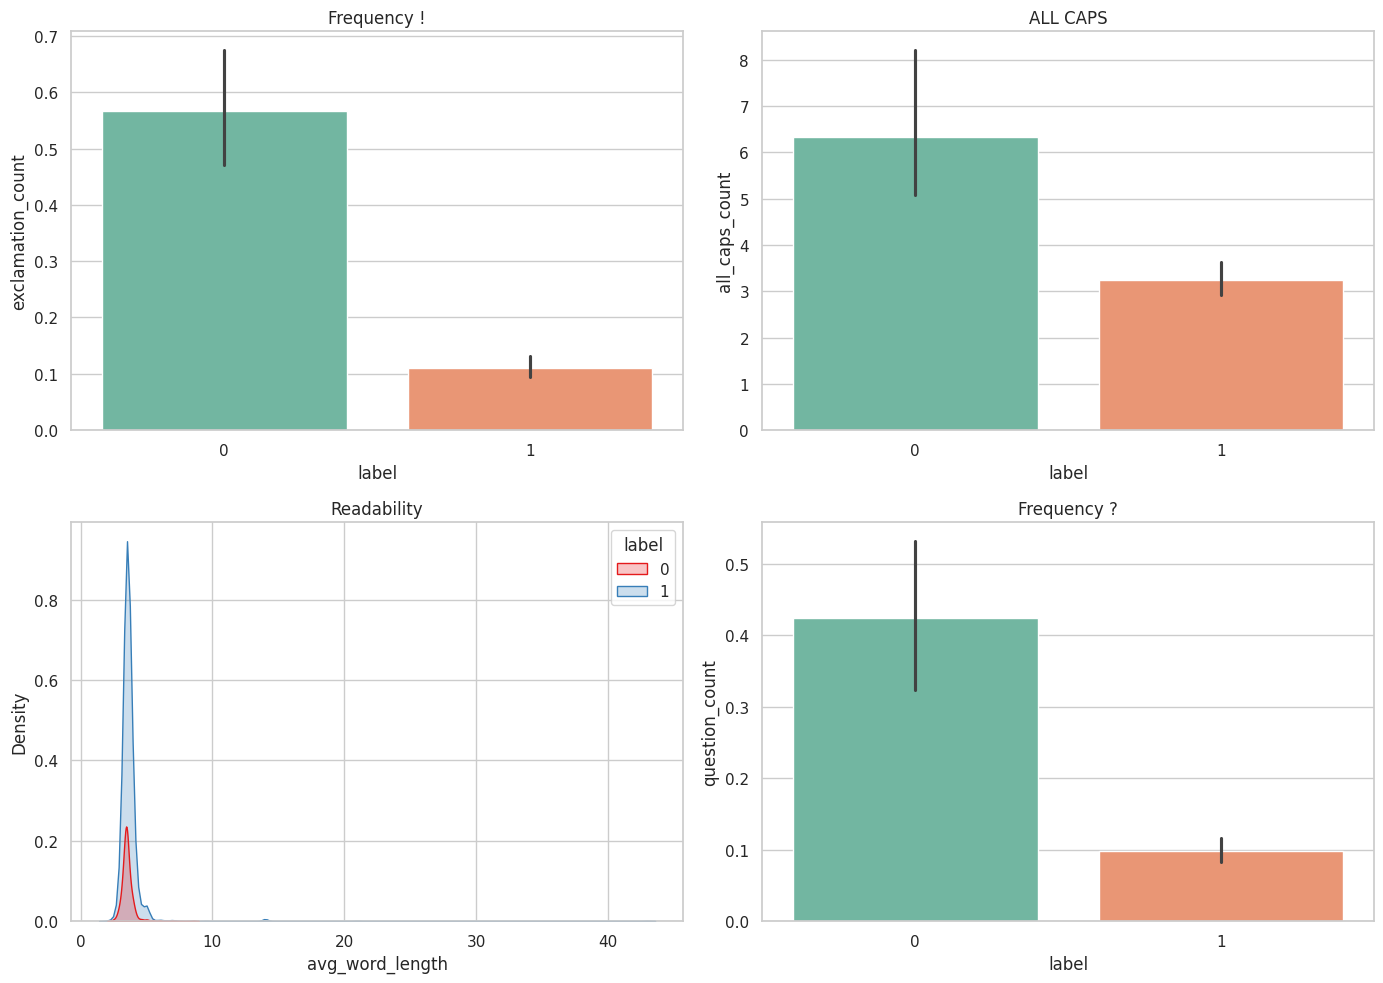

PHẦN 2: LEXICAL ANALYSIS & TTR (Sự phong phú từ vựng)
  Class  Total Words  Unique Words  TTR (Type-Token Ratio)
0  Fake        76082          7682                0.100970
1  Real       161679         13499                0.083493

PHẦN 3: TF-IDF KEYWORD DISCOVERY
--- Top 10 TF-IDF Keywords (Fake) ---
      Word      Score
857     và  36.208963
420     là  34.930170
178     có  34.664751
523  người  33.745998
379  không  29.622015
221    của  29.302962
170    các  26.657823
96     cho  26.387054
73      bị  25.255463
942     đã  24.243779

--- Top 10 TF-IDF Keywords (Real) ---
        Word       Score
855       và  131.335019
236      của  125.129269
197       có  123.561794
516    người  117.911620
188      các  112.953097
758    trong  107.157576
179  covid19  106.802555
935       đã  106.465590
423       là  101.095146
121      cho   99.817991

PHẦN 4: EMBEDDING VISUALIZATION (PCA)


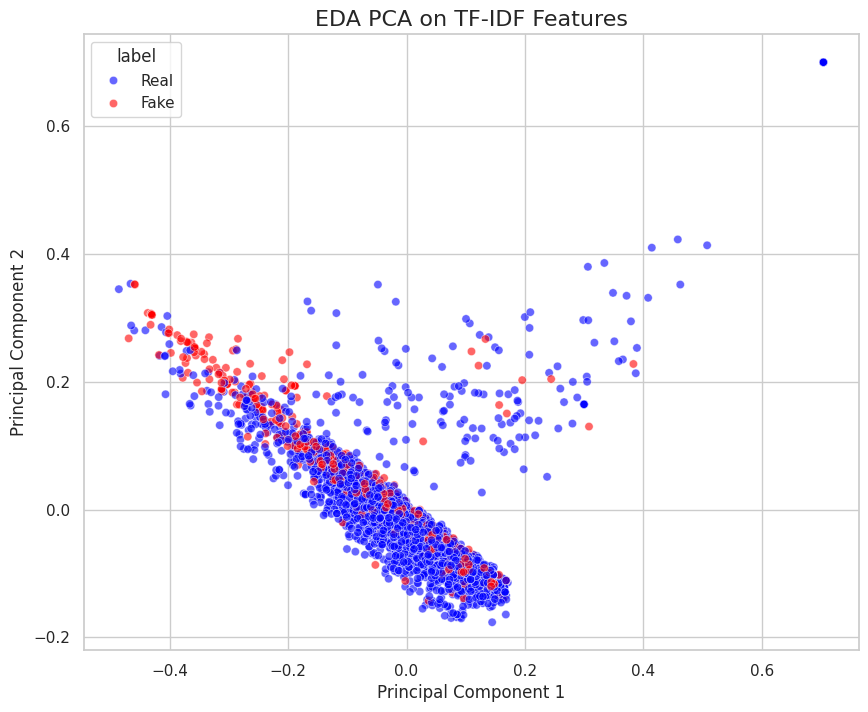

In [18]:
sns.set_theme(style="whitegrid")

print("="*50)
print("PHẦN 1: FEATURE ENGINEERING (READABILITY & STYLE)")
print("="*50)

# 1. Punctuation Analysis (Đếm dấu chấm than, chấm hỏi)
df['exclamation_count'] = df['title'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['title'].apply(lambda x: str(x).count('?'))

# 2. Capitalization Analysis (Đếm số từ IN HOA TOÀN BỘ)
def count_all_caps(text):
    words = str(text).split()
    return sum(1 for word in words if word.isupper() and len(word) > 1)

df['all_caps_count'] = df['title'].apply(count_all_caps)

# 3. Readability (Độ dài trung bình của 1 từ)
def avg_word_length(text):
    words = str(text).split()
    if not words: return 0
    return sum(len(word) for word in words) / len(words)

df['avg_word_length'] = df['title'].apply(avg_word_length)

# Trực quan hóa các Features vừa tạo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=df, x='label', y='exclamation_count', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Frequency !')

sns.barplot(data=df, x='label', y='all_caps_count', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('ALL CAPS')

sns.kdeplot(data=df, x='avg_word_length', hue='label', fill=True, ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Readability')

sns.barplot(data=df, x='label', y='question_count', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Frequency ?')

plt.tight_layout()
plt.show()

print("="*50)
print("PHẦN 2: LEXICAL ANALYSIS & TTR (Sự phong phú từ vựng)")
print("="*50)

def calculate_ttr(corpus):
    words = ' '.join(corpus).split()
    total_words = len(words)
    unique_words = len(set(words))
    ttr = unique_words / total_words if total_words > 0 else 0
    return total_words, unique_words, ttr

# Tách corpus (Giả định nhãn 0 là Fake, 1 là Real)
fake_corpus = df[df['label'] == 0]['clean_title']
real_corpus = df[df['label'] == 1]['clean_title']

f_total, f_unique, f_ttr = calculate_ttr(fake_corpus)
r_total, r_unique, r_ttr = calculate_ttr(real_corpus)

# Tạo bảng thống kê Lexical
ttr_df = pd.DataFrame({
    'Class': ['Fake', 'Real'],
    'Total Words': [f_total, r_total],
    'Unique Words': [f_unique, r_unique],
    'TTR (Type-Token Ratio)': [f_ttr, r_ttr]
})
print(ttr_df)

print("\n" + "="*50)
print("PHẦN 3: TF-IDF KEYWORD DISCOVERY")
print("="*50)

def get_top_tfidf_words(corpus, top_n=10):
    # Khởi tạo TF-IDF (thêm stop_words nếu bạn đã tải list tiếng Việt)
    tfidf = TfidfVectorizer(max_features=1000)
    tfidf_matrix = tfidf.fit_transform(corpus)

    # Tính tổng trọng số TF-IDF của từng từ
    sum_tfidf = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

    # Ghép từ và điểm số
    tfidf_scores = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Score': sum_tfidf})
    return tfidf_scores.sort_values(by='Score', ascending=False).head(top_n)

print("--- Top 10 TF-IDF Keywords (Fake) ---")
print(get_top_tfidf_words(fake_corpus))
print("\n--- Top 10 TF-IDF Keywords (Real) ---")
print(get_top_tfidf_words(real_corpus))

print("\n" + "="*50)
print("PHẦN 4: EMBEDDING VISUALIZATION (PCA)")
print("="*50)
# Giảm chiều dữ liệu text để vẽ lên mặt phẳng 2D
# Giúp xem hai cụm Fake và Real có tách rời nhau không

vectorizer = TfidfVectorizer(max_features=500) # Lấy 500 từ quan trọng nhất
X_tfidf = vectorizer.fit_transform(df['clean_title']).toarray()

# Dùng PCA giảm từ 500 chiều xuống 2 chiều
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf)

# Tạo DataFrame để vẽ đồ thị
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = df['label'].map({0: 'Fake', 1: 'Real'}) # Đổi số sang chữ cho đồ thị đẹp

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', palette={'Fake': 'red', 'Real': 'blue'}, alpha=0.6)
plt.title('EDA PCA on TF-IDF Features', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [19]:
print("\n--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---")

# Khởi tạo bộ Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit và Transform trên Train
X_train = vectorizer.fit_transform(train_df['clean_title'])
y_train = train_df['label']

# Chỉ Transform trên Val và Test
X_val = vectorizer.transform(val_df['clean_title'])
y_val = val_df['label']

X_test = vectorizer.transform(test_df['clean_title'])
y_test = test_df['label']

# ==========================================
# 4. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH
# ==========================================
print("\n--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---")

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_list = []

for model_name, model in models.items():
    # Huấn luyện trên Train
    model.fit(X_train, y_train)

    # Đánh giá trên Test (Nếu muốn chỉnh hyperparameter, hãy đổi X_test thành X_val)
    y_pred = model.predict(X_test)

    # Tính toán Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Ghi nhận kết quả
    results_list.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

print("\n--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

--- 1. ĐANG TẢI VÀ CHIA TẬP DỮ LIỆU ---
Tổng số mẫu: 4372
Số lượng phân bổ - Train: 3060 | Val: 656 | Test: 656

--- 2. ĐANG LÀM SẠCH VÀ TOKENIZE TEXT ---

--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---

--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---

--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
        Model  Accuracy  Precision  Recall     F1
  Naive Bayes    0.8399     0.8427  0.8399 0.7764
     Logistic    0.8567     0.8502  0.8567 0.8176
          SVM    0.8704     0.8588  0.8704 0.8490
Random Forest    0.8537     0.8383  0.8537 0.8168


In [20]:

print("--- GIAI ĐOẠN 3: HUẤN LUYỆN BILSTM ---")

# 1. Chuẩn bị dữ liệu chuỗi (Sequences) thay vì TF-IDF
MAX_VOCAB = 10000  # Giữ lại 10.000 từ phổ biến nhất
MAX_LEN = 100      # Cắt hoặc đệm (pad) tiêu đề về đúng 100 từ

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
# Lưu ý: Train tokenizer trên tập train để tránh data leakage
tokenizer.fit_on_texts(train_df['clean_title'])

# Chuyển chữ thành các dãy số (index) và đệm cho bằng nhau
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_title']), maxlen=MAX_LEN, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_title']), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_title']), maxlen=MAX_LEN, padding='post')

# 2. Xây dựng kiến trúc mô hình BiLSTM
model_bilstm = Sequential([
    # Layer 1: Embedding (Học vector không gian cho từng từ)
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),

    # Layer 2: BiLSTM (Đọc ngữ cảnh từ trái sang phải và phải sang trái)
    Bidirectional(LSTM(64, return_sequences=False)),

    # Layer 3: Tránh học vẹt (Overfitting)
    Dropout(0.5),

    # Layer 4: Phân loại nhị phân (Fake/Real)
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Dùng sigmoid cho classification 2 lớp
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

# 3. Huấn luyện mô hình
history = model_bilstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=5,
    batch_size=64
)

# Đánh giá trên tập Test
test_loss, test_acc = model_bilstm.evaluate(X_test_seq, y_test)
print(f"BiLSTM Test Accuracy: {test_acc:.4f}")

--- GIAI ĐOẠN 3: HUẤN LUYỆN BILSTM ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.8248 - loss: 0.4664 - val_accuracy: 0.8323 - val_loss: 0.4283
Epoch 2/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8523 - loss: 0.3477 - val_accuracy: 0.8354 - val_loss: 0.4077
Epoch 3/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8997 - loss: 0.2301 - val_accuracy: 0.8186 - val_loss: 0.4855
Epoch 4/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9474 - loss: 0.1379 - val_accuracy: 0.7881 - val_loss: 0.6553
Epoch 5/5
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9696 - loss: 0.0817 - val_accuracy: 0.7957 - val_loss: 0.7001
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8216 - loss: 0.5382
BiLSTM Test Accuracy: 0.8216


In [21]:

print("--- GIAI ĐOẠN 4: FINE-TUNE PHOBERT ---")

# 1. Tải PhoBERT Tokenizer và Model
model_name = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
# num_labels=2 vì chúng ta phân loại Fake (0) và Real (1)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# --- BƯỚC BỔ SUNG: LÀM SẠCH DỮ LIỆU ---
# Loại bỏ các dòng có giá trị rỗng (NaN/None) ở cột 'title' để tránh lỗi Tokenizer
train_df_clean = train_df[['title', 'label']].dropna(subset=['title']).copy()
val_df_clean = val_df[['title', 'label']].dropna(subset=['title']).copy()
test_df_clean = test_df[['title', 'label']].dropna(subset=['title']).copy()

# Ép kiểu cột 'title' về dạng string cho chắc chắn
train_df_clean['title'] = train_df_clean['title'].astype(str)
val_df_clean['title'] = val_df_clean['title'].astype(str)
test_df_clean['title'] = test_df_clean['title'].astype(str)

# 2. Chuyển đổi DataFrame sang định dạng Dataset của Hugging Face
train_dataset = Dataset.from_pandas(train_df_clean.rename(columns={'title': 'text'}))
val_dataset = Dataset.from_pandas(val_df_clean.rename(columns={'title': 'text'}))
test_dataset = Dataset.from_pandas(test_df_clean.rename(columns={'title': 'text'}))

# Xóa cột index dư thừa do pandas tự sinh ra (nếu có)
for dataset in [train_dataset, val_dataset, test_dataset]:
    if '__index_level_0__' in dataset.column_names:
        dataset = dataset.remove_columns(['__index_level_0__'])

# Hàm tokenize chuẩn của PhoBERT
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Map hàm tokenize
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# 3. Thiết lập tham số huấn luyện (Training Arguments)
training_args = TrainingArguments(
    output_dir="./phobert_fake_news",
    eval_strategy="epoch",        # Dùng eval_strategy thay vì evaluation_strategy (cập nhật mới của HF)
    learning_rate=2e-5,           # Learning rate cực nhỏ để fine-tune
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,           # Transformer thường chỉ cần 3-5 epochs
    weight_decay=0.01,
    logging_dir='./logs',
)

# 4. Khởi tạo Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# Tiến hành Fine-tune
print("Bắt đầu huấn luyện PhoBERT...")
trainer.train()

# Đánh giá trên tập Test
print("Đánh giá trên tập Test...")
predictions = trainer.predict(test_dataset)
print(predictions.metrics)

--- GIAI ĐOẠN 4: FINE-TUNE PHOBERT ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss
1,No log,0.369093
2,No log,0.373909
3,0.309441,0.438591


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đánh giá trên tập Test...


{'test_loss': 0.38577765226364136, 'test_runtime': 5.0346, 'test_samples_per_second': 129.902, 'test_steps_per_second': 8.144}



Đang xuất kết quả cho BiLSTM...
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

--- KẾT QUẢ: BILSTM ---
Accuracy : 0.8216
Precision: 0.821
Recall   : 0.8216
F1-Score : 0.8213


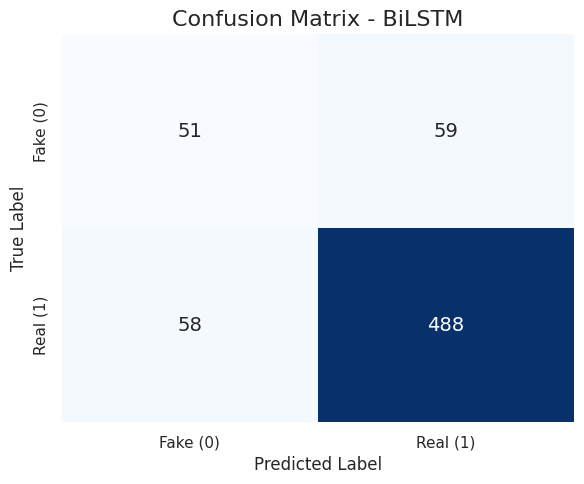


Đang xuất kết quả cho PhoBERT...



--- KẾT QUẢ: PHOBERT ---
Accuracy : 0.8578
Precision: 0.8391
Recall   : 0.8578
F1-Score : 0.8375


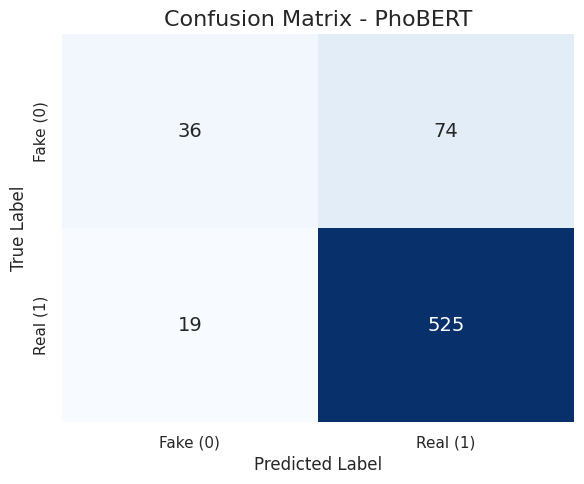

In [22]:
# ==========================================
# 1. HÀM TÍNH METRICS VÀ VẼ CONFUSION MATRIX
# ==========================================
def evaluate_and_plot_cm(y_true, y_pred, model_name="Model"):
    # Tính toán 4 chỉ số
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n--- KẾT QUẢ: {model_name.upper()} ---")
    print(f"Accuracy : {round(acc, 4)}")
    print(f"Precision: {round(prec, 4)}")
    print(f"Recall   : {round(rec, 4)}")
    print(f"F1-Score : {round(f1, 4)}")

    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))

    # Dùng seaborn heatmap để vẽ cho đẹp
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'],
                annot_kws={"size": 14}) # Phóng to chữ số bên trong

    plt.title(f'Confusion Matrix - {model_name}', fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. ÁP DỤNG CHO BILSTM
# ==========================================
print("\nĐang xuất kết quả cho BiLSTM...")
# BiLSTM xuất ra xác suất (0.0 đến 1.0) do dùng hàm sigmoid
bilstm_probs = model_bilstm.predict(X_test_seq)

# Ép xác suất thành nhãn 0 hoặc 1 (ngưỡng 0.5)
bilstm_preds = (bilstm_probs > 0.5).astype(int).flatten()

evaluate_and_plot_cm(y_test, bilstm_preds, model_name="BiLSTM")

# ==========================================
# 3. ÁP DỤNG CHO PHOBERT (Nếu bạn chạy cả GĐ4)
# ==========================================
print("\nĐang xuất kết quả cho PhoBERT...")
# Trainer của HuggingFace trả về đối tượng PredictionOutput
phobert_output = trainer.predict(test_dataset)

# Lấy nhãn thực tế từ test_dataset
y_true_phobert = phobert_output.label_ids

# Lấy logits (điểm số thô) và dùng argmax để chọn class có điểm cao nhất
phobert_preds = np.argmax(phobert_output.predictions, axis=1)

evaluate_and_plot_cm(y_true_phobert, phobert_preds, model_name="PhoBERT")

--- 1. ĐANG TẢI VÀ CHIA TẬP DỮ LIỆU ---
Tổng số mẫu: 4372
Số lượng phân bổ - Train: 3060 | Val: 656 | Test: 656

--- 2. ĐANG LÀM SẠCH VÀ TOKENIZE TEXT ---

--- 3. ĐANG VECTOR HÓA DỮ LIỆU (TF-IDF) ---

--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---

--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---
        Model  Accuracy  Precision  Recall     F1
  Naive Bayes    0.8399     0.8427  0.8399 0.7764
     Logistic    0.8567     0.8502  0.8567 0.8176
          SVM    0.8704     0.8588  0.8704 0.8490
Random Forest    0.8537     0.8383  0.8537 0.8168

--- 6. ĐANG VẼ CONFUSION MATRIX ---


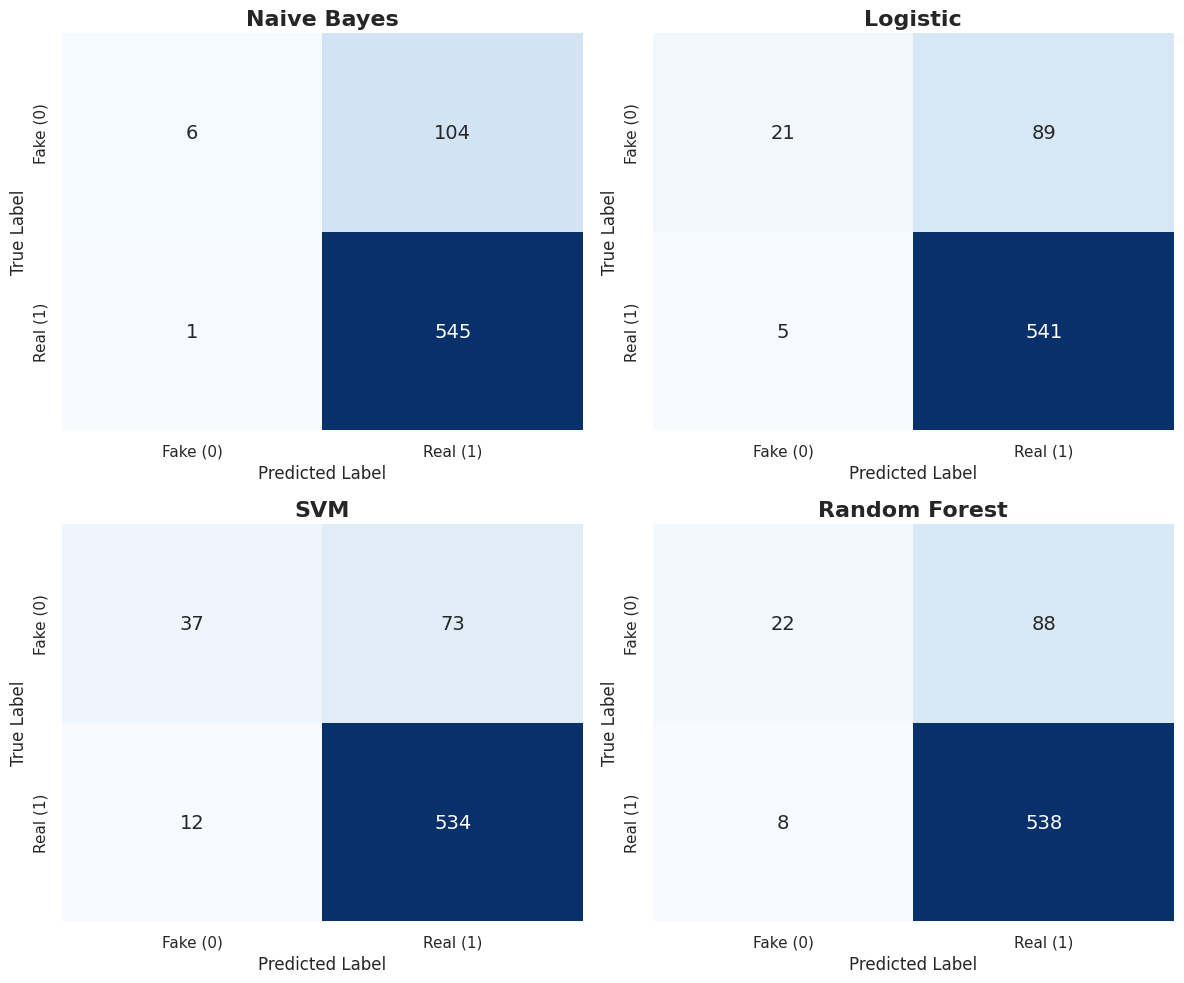

In [23]:
print("\n--- 4. ĐANG HUẤN LUYỆN CÁC MÔ HÌNH (TRAINING) ---")

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results_list = []
cm_dict = {} # Dictionary để lưu trữ Confusion Matrix của từng mô hình

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Tính toán các chỉ số
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Tính và lưu Confusion Matrix
    cm_dict[model_name] = confusion_matrix(y_test, y_pred)

    results_list.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

# ==========================================
# 5. HIỂN THỊ KẾT QUẢ VÀ CONFUSION MATRIX
# ==========================================
print("\n--- 5. KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST ---")
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

print("\n--- 6. ĐANG VẼ CONFUSION MATRIX ---")
# Tạo một khung ảnh (Figure) chứa 4 biểu đồ con (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Trải phẳng mảng 2x2 thành 1D để dễ lặp qua

for i, (model_name, cm) in enumerate(cm_dict.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                annot_kws={"size": 14}) # Cỡ chữ của số liệu bên trong

    axes[i].set_title(f'{model_name}', fontsize=16, fontweight='bold')

    # Đặt tên trục (Giả định nhãn 0 là Fake, 1 là Real. Bạn có thể sửa lại nếu data của bạn khác)
    axes[i].set_xticklabels(['Fake (0)', 'Real (1)'])
    axes[i].set_yticklabels(['Fake (0)', 'Real (1)'])
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()